IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LOAD DATASET

In [2]:
df = pd.read_csv("Housing.csv")

print(df.head())
print(df.info())
print(df.describe())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

CONVERT CATEGORICAL VARIABLES

In [3]:
df = pd.get_dummies(df, drop_first=True)


In [4]:
# FEATURES AND TERGETS
X = df.drop('price', axis=1)
y = df['price']


# Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

TRAIN MODEL

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

PREDICTION

In [7]:
y_pred = model.predict(X_test)

EVALUATION

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 970043.4039201636
MSE : 1754318687330.6638
R2 Score : 0.6529242642153184


COEFFICIENTS

In [9]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

                            Feature   Coefficient
0                              area  2.359688e+02
1                          bedrooms  7.677870e+04
2                         bathrooms  1.094445e+06
3                           stories  4.074766e+05
4                           parking  2.248419e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
7                      basement_yes  3.902512e+05
8               hotwaterheating_yes  6.846499e+05
9               airconditioning_yes  7.914267e+05
10                     prefarea_yes  6.298906e+05
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05


ACTUAL VS PREDICTED

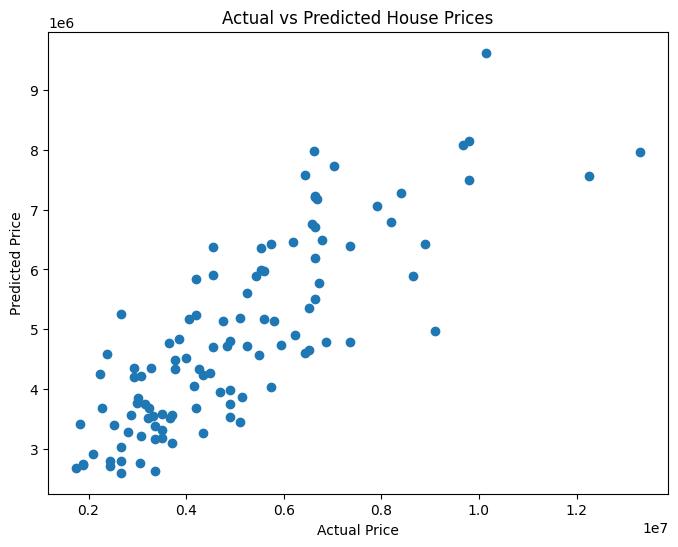

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

SIMPLE LINEAR REGRESSION
Use only area to predict price.

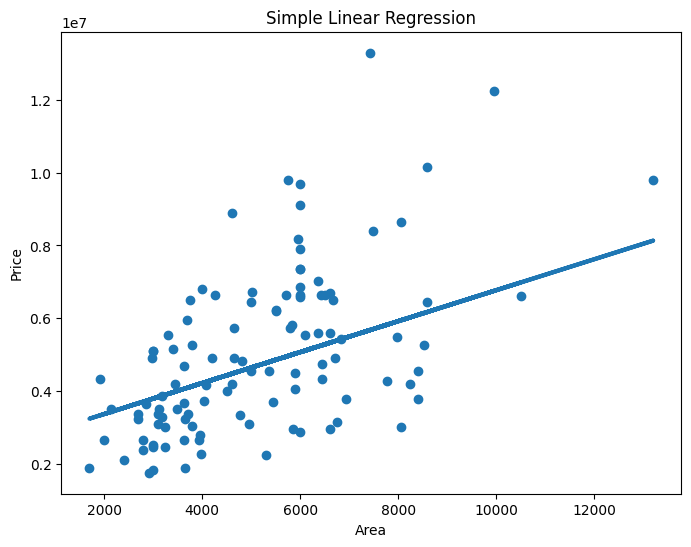

In [11]:
X_simple = df[['area']]
y_simple = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred = simple_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test)

plt.plot(
    X_test,
    y_pred,
    linewidth=3
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()